In [55]:
import os
import random
import string
import math

import hail as hl
from ukb_utils import hail_init
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from ko_utils import ko
from ko_utils import samples
from ko_utils.ko import PLOF_CSQS, MISSENSE_CSQS, SYNONYMOUS_CSQS, OTHER_CSQS
import scipy.stats as stats

In [2]:
os.chdir('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb/')
hail_init.hail_bmrc_init('logs/hail/hail_test_export.log', 'GRCh38')

Running on Apache Spark version 3.1.2
SparkUI available at http://compa039.hpc.in.bmrc.ox.ac.uk:4040
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.77-684f32d73643
LOGGING: writing to logs/hail/hail_test_export.log


In [5]:
def normalize_dosages(dosages):
    r"""Normalizes dosages to have mean 0 and variance 1 at each SNP Parameters
    """
    mt = dosages._indices.source
    mt = mt.annotate_rows(**{'gt_stats_'+tid: hl.agg.stats(mt.DS)})
    mt = mt.annotate_entries(norm_ds=(mt.DS-mt.DS.mean)/mt.DS.stdev)
    return mt

# Standard simulation of genotypes using Hail

In [292]:
# parameters
h2 = 0.2
pi = None #0.002
n = 1000

In [293]:
# simulate SNPs 
mt = hl.balding_nichols_model(1, 5000, n, reference_genome='GRCh38')
mt = mt.transmute_entries(GT = ko.set_to_phased_call(mt.GT))
mt = hl.experimental.ldscsim.make_betas(mt, h2, pi = pi)[0]

2022-04-06 14:51:47 Hail: INFO: balding_nichols_model: generating genotypes for 1 populations, 5000 samples, and 1000 variants...


In [294]:
# standardize SNPs
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)

In [295]:
# add noise component
mt = mt.annotate_cols(y_no_noise=hl.agg.sum(mt.beta * mt['norm_gt']))
mt = mt.annotate_cols(y=mt.y_no_noise + hl.rand_norm(0, hl.sqrt(1-h2)))
print(np.var(mt.y.collect()))
print(np.var(mt.y_no_noise.collect()))

0.9807799351930025
0.203589771132522


In [749]:
ht = hl.linear_regression_rows(y=mt.y,
                               x=mt.GT.n_alt_alleles(),
                                covariates=[1])

2022-04-05 11:46:35 Hail: INFO: Coerced sorted dataset
2022-04-05 11:46:36 Hail: INFO: linear_regression_rows: running on 5000 samples for 1 response variable y,
    with input variable x, and 1 additional covariate...


In [750]:
rows = ht.count()
p_expected = [ -math.log10((x+1) / rows) for x in range(rows)]
p_observed = [ -math.log10(x) for x in ht.p_value.collect()]
p_observed.sort()
p_expected.sort()
x = p_expected[::-1]
y = p_observed[::-1]

In [751]:
beta = mt.beta.collect()
true_hits = np.where(np.abs(np.array(beta)) > 0)[0]

2022-04-05 11:46:37 Hail: INFO: Coerced sorted dataset


In [752]:
ps = np.array(p_observed)
bonf = -math.log10(0.05/rows)
hits = np.where(ps > bonf)[0]

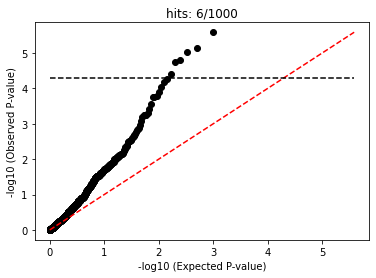

In [753]:
limit = max([max(x), max(y)])
fig, ax = plt.subplots()
plt.scatter(x,y,color='black')
plt.plot([0, limit],[0, limit], "--", color = 'red', zorder=1)
plt.plot([0, limit],[bonf, bonf], "--",color = 'black', zorder=1)
plt.xlabel("-log10 (Expected P-value)")
plt.ylabel("-log10 (Observed P-value)")
plt.title("hits: " + str(len(hits)) + "/" + str(len(true_hits)))
plt.show()

# Simulating in Hail using binary phenotypes

In [882]:
# parameters
h2 = 0.2
pi = None #0.002
n = 1000
K = 0.1 # cases/(cases+controls)

In [885]:
# simulate SNPs 
mt = hl.balding_nichols_model(1, 5000, n, reference_genome='GRCh38')
mt = mt.transmute_entries(GT = ko.set_to_phased_call(mt.GT))
mt = hl.experimental.ldscsim.make_betas(mt, h2, pi = pi)[0]

# standardize SNPs
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)

# add noise component
mt = mt.annotate_cols(y_no_noise=hl.agg.sum(mt.beta * mt['norm_gt']))
mt = mt.annotate_cols(y=mt.y_no_noise + hl.rand_norm(0, hl.sqrt(1-h2)))
mt = hl.experimental.ldscsim.binarize(mt, mt.y, K)
print(sum(mt.y_binarized.collect()))

# logistic regression
ht = hl.logistic_regression_rows(
     test='wald',
     y=mt.y_binarized,
     x=mt.GT.n_alt_alleles(),
     covariates=[1])

2022-04-05 15:06:40 Hail: INFO: balding_nichols_model: generating genotypes for 1 populations, 5000 samples, and 1000 variants...


482


2022-04-05 15:06:44 Hail: INFO: Coerced sorted dataset
2022-04-05 15:06:44 Hail: INFO: logistic_regression_rows: running wald on 5000 samples for response variable y,
    with input variable x, and 1 additional covariate...


# Simulation of spike and slab using UKBB genotypes with zero heritability

In [854]:
# parameters
sim = 100
h2 = 0
pi = None 
n = 1000

In [855]:
mt = hl.read_matrix_table('data/simulation/data/ukb_eur_10000_samples_chr21.mt')
mt = mt.explode_rows(mt.consequence.vep.worst_csq_by_gene_canonical)
mt = mt.annotate_rows(
    consequence_category=ko.csqs_case_builder(
            worst_csq_expr=mt.consequence.vep.worst_csq_by_gene_canonical,
            use_loftee=True)
        )

In [856]:
mt = hl.experimental.ldscsim.make_betas(mt, h2, pi = pi)[0]
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)

In [857]:
# add noise component
mt = mt.annotate_cols(y_no_noise=hl.agg.sum(mt.beta * mt['norm_gt']))

In [858]:
for i in range(sim):
    col = "y" + str(i)
    y = mt.y_no_noise + hl.rand_norm(0, hl.sqrt(1-h2))
    mt = mt.annotate_cols(y = y)
    mt = mt.rename({'y': col})
    
    

# Simulation of compound het effects with Hail

In [338]:
def get_gene(length=5):
    r"""Internal method for getting random genes"""
    return ''.join(random.choices(string.ascii_uppercase, k=length))

In [373]:
# parameters
sim = 100
h2_snp = 0.2
h2_ch = 0.05
pi_snp = None
pi_ch = None

n = 1000

In [449]:
# simulate SNPs 
mt = hl.balding_nichols_model(3, 1000, n, reference_genome='GRCh38')
mt = mt.transmute_entries(GT = ko.set_to_phased_call(mt.GT))
mt = mt.transmute_entries(GT = ko.rand_flip_call(mt.GT))
mt = hl.experimental.ldscsim.make_betas(mt, h2_snp, pi = pi_snp)[0]

# standardize SNPs
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)

# add noise component
#mt = mt.annotate_cols(y_no_noise=hl.agg.sum(mt.beta * mt['norm_gt']))
#mt = mt.annotate_cols(y=mt.y_no_noise + hl.rand_norm(0, hl.sqrt(1-h2)))

2022-04-06 17:08:59 Hail: INFO: balding_nichols_model: generating genotypes for 3 populations, 1000 samples, and 1000 variants...


(0, 1000)

In [447]:
#mt.filter_rows(hl.agg.call_stats(mt.GT, mt.alleles)[].homozygote_count > 2)
#hl.variant_qc(mt).describe()

TypeError: Invalid '>' comparison, cannot compare expressions of type 'array<int32>' and 'int32'

In [377]:
# need to simulate genes
n_genes = 25
mt = mt.annotate_rows(gene = hl.str(hl.rand_cat([1]*n_genes )))

gene_expr = mt.gene
genes = ko.aggr_phase_count_by_expr(mt, gene_expr)
expr_pko = ko.calc_prob_ko(genes.hom_alt_n, genes.phased, genes.unphased)
expr_ko = ko.annotate_knockout(genes.hom_alt_n, expr_pko)
genes = genes.annotate_entries(
            pKO=expr_pko,
            knockout=expr_ko)

#genes = genes.filter_entries(genes.knockout == "Compound heterozygote")


In [365]:
np.unique(np.array(x))

array(['Compound heterozygote', 'Homozygote'], dtype='<U21')

# simulation if compound het effects in UKBB

In [3]:
def rand_hom_to_het(gt: hl.call, P: float = 0.9, seed = None):
    """ Randomize genotype phase of call
    :param gt: genotype call to be flipped
    :param P: probabily of flipping hom to het
    :param seed: seed for random
    """
    assert str(gt.dtype) == 'call'

    return hl.if_else(
        (gt.n_alt_alleles() == 2),
        hl.if_else(
            (hl.rand_bool(P, seed=seed)),
            hl.if_else(
                (hl.rand_bool(0.5, seed=seed)),
                hl.parse_call("1|0"),
                hl.parse_call("0|1")
            ),
            gt
        ),
        gt
    )

In [48]:
def try_set_float(x):
    return float(x) if x not in [None, "NA","None"] else None

In [99]:
# parameters
sim = 100
h2_snp = 0.1
h2_ko = 0.2
pi_snp = 0.1
pi_ko = 0.5
K = "NA"
n = 1000
prune_hom_alt = 0.98

In [100]:
# Heritability must be specified
h2_snp = try_set_float(h2_snp)
h2_ko = try_set_float(h2_ko)
pi_snp = try_set_float(pi_snp)
pi_ko = try_set_float(pi_ko)
K = try_set_float(K)

In [101]:
mt = hl.read_matrix_table('data/simulation/data/ukb_eur_10000_samples_chr21.mt')

In [102]:
# annotate with variant consequence
mt = mt.explode_rows(mt.consequence.vep.worst_csq_by_gene_canonical)
mt = mt.annotate_rows(
consequence_category=ko.csqs_case_builder(
    worst_csq_expr=mt.consequence.vep.worst_csq_by_gene_canonical,
    use_loftee=True))

In [103]:
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.make_betas(mt, h2=h2_snp, pi=pi_snp)[0]
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)
mt = mt.annotate_cols(y_no_noise_snp=hl.agg.sum(mt.beta * mt['norm_gt']))

In [106]:
# annotate with CH effect
if h2_ko is not None:

    gene_mt = mt

    # prune away knockedout owed to homozygote alternates
    if prune_hom_alt:
        prune_hom_alt = float(prune_hom_alt)
        gene_mt = gene_mt.transmute_entries(GT = ko.rand_hom_to_het(gene_mt.GT, prune_hom_alt))

    # generate gene x sample matrix
    gene_expr = gene_mt.consequence.vep.worst_csq_by_gene_canonical.gene_id
    genes = ko.aggr_phase_count_by_expr(gene_mt, gene_expr)
    expr_pko = ko.calc_prob_ko(genes.hom_alt_n, genes.phased, genes.unphased)
    expr_ko = ko.annotate_knockout(genes.hom_alt_n, expr_pko)
    genes = genes.annotate_entries(pKO=expr_pko, knockout=expr_ko)

    # simulate thetas
    genes = genes.filter_rows(hl.agg.stats(genes.pKO).stdev>0)
    genes = normalize_by_name(genes, "pKO") # <---- set library
    genes = ko.make_thetas(genes, h2=h2_ko, pi=pi_ko)
    genes = genes.annotate_cols(y_no_noise_ko=hl.agg.sum(genes.theta * genes.norm_pKO))
    
    # return thetas for genes and samples
    ht = genes.select_rows('theta').select_entries('pKO')
    #ht.entries().flatten().export(out_prefix + "_genes.tsv.gz")

    # annotate original matrix with thetas from gene x sample matrix
    mt = mt.annotate_cols(y_no_noise_ko = genes.index_cols(mt.col_key).y_no_noise_ko)
    mt = mt.annotate_cols(y_cts=mt.y_no_noise_snp +
            mt.y_no_noise_ko + hl.rand_norm(0, hl.sqrt(1-h2_ko-h2_snp)))
else:
    mt = mt.annotate_cols(y_cts = mt.y_no_noise_snp +
            hl.rand_norm(0, hl.sqrt(1-h2_snp)))

if K is not None:
    y_stats = mt.aggregate_cols(hl.agg.stats(mt.y_cts))
    threshold = stats.norm.ppf(1-K, loc=y_stats.mean, scale=y_stats.stdev)
    mt = mt.annotate_cols(y_bin=mt.y_cts > threshold)

2022-04-07 10:03:41 Hail: INFO: Ordering unsorted dataset with network shuffle


In [93]:
genes.select_rows('theta').select_entries('pKO').entries().flatten().describe()

----------------------------------------
Global fields:
    None
----------------------------------------
Row fields:
    'gene_id': str 
    'theta': float64 
    's': str 
    'y_no_noise_snp': float64 
    'y_no_noise_ko': float64 
    'pKO': float64 
----------------------------------------
Key: []
----------------------------------------


In [41]:
mt = hl.read_matrix_table('data/simulation/data/ukb_eur_10000_samples_chr21.mt')
mt = mt.explode_rows(mt.consequence.vep.worst_csq_by_gene_canonical)
mt = mt.annotate_rows(
    consequence_category=ko.csqs_case_builder(
            worst_csq_expr=mt.consequence.vep.worst_csq_by_gene_canonical,
            use_loftee=True)
        )

# subset to current csqs category
items = ['pLoF','damaging_missense']
mt = mt.filter_rows(hl.literal(set(items)).contains(mt.consequence_category))

print(mt.aggregate_entries(hl.agg.counter(mt.GT.is_hom_var())))
mt = mt.transmute_entries(GT = rand_hom_to_het(mt.GT, 0.95))
print(mt.aggregate_entries(hl.agg.counter(mt.GT.is_hom_var())))

#mt = mt.annotate_rows(n_alt_hom = hl.agg.call_stats(mt.GT, mt.alleles).homozygote_count[1])
#mt = mt.filter_rows(mt.n_alt_hom > 0)
#print(mt.count())

frozendict({False: 36309398, True: 602})
frozendict({False: 36309965, True: 35})


In [37]:
mt.aggregate_entries(hl.agg.counter(mt.GT.is_hom_var()))

frozendict({False: 6157496, True: 2504})

In [39]:

2521693 * 0.999


2519171.307

In [42]:
# get betas
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.make_betas(mt, h2 = h2_snp, pi = pi_snp)[0]
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)
mt = mt.annotate_cols(y_no_noise_snp=hl.agg.sum(mt.beta * mt['norm_gt']))


In [43]:
# get thetas
gene_expr = mt.consequence.vep.worst_csq_by_gene_canonical.gene_id
genes = ko.aggr_phase_count_by_expr(mt, gene_expr)
expr_pko = ko.calc_prob_ko(genes.hom_alt_n, genes.phased, genes.unphased)
expr_ko = ko.annotate_knockout(genes.hom_alt_n, expr_pko)
genes = genes.annotate_entries(
            pKO=expr_pko,
            knockout=expr_ko)

In [46]:
# 
counts = genes.aggregate_entries(hl.agg.counter(genes.knockout))


2022-04-06 17:42:15 Hail: INFO: Ordering unsorted dataset with network shuffle


In [48]:
counts = genes.aggregate_entries(hl.agg.counter(genes.knockout))
n_homs = counts['Homozygote']
n_ch = counts['Compound heterozygote']

In [49]:
n_ch 

9

In [50]:
n_homs

35

In [403]:
#x = genes
genes = genes.filter_rows(hl.agg.stats(genes.pKO).stdev>0)
genes = normalize_by_name(genes, "pKO")
genes = make_thetas(genes, h2 = h2_ch, pi = pi_ch)
genes = genes.annotate_cols(y_no_noise=hl.agg.sum(genes.theta * genes.norm_pKO))

2022-04-06 15:19:53 Hail: INFO: Ordering unsorted dataset with network shuffle


In [404]:
mt = mt.annotate_cols(y_no_noise_ch = genes.index_cols(mt.col_key).y_no_noise)
mt = mt.annotate_cols(y=mt.y_no_noise_snp + mt.y_no_noise_ch + hl.rand_norm(0, hl.sqrt(1-h2_ch-h2_snp)))

In [51]:
#mt = mt.checkpoint('data/tmp/mt_checkpoint.mt', overwrite = True)
#x = mt
mt = x


NameError: name 'x' is not defined

In [407]:
print(np.var(mt.y.collect()))

test = mt.y_no_noise_snp + mt.y_no_noise_ch
print(np.var(mt.y_no_noise_snp.collect()))
print(np.var(mt.y_no_noise_ch.collect()))


#np.var(test.collect())

0.9733276930148409
0.19552562989109723
0.051731041663673274


0.05

In [77]:
def normalize_by_name(mt, name):
    """Normalize entry to have mean of zero and variance of 1"""
    mt = mt.annotate_rows(**{'stats': hl.agg.stats(mt[name])})
    mt = mt.annotate_entries(
        norm=(mt[name]-mt.stats.mean)/mt.stats.stdev)
    mt = mt.rename({"norm" : "norm_" + str(name)})
    return(mt)


def make_thetas(mt, h2, pi = None):
    """ Make thetas (effect sizes) for genes (gene x sample matrix) with
    either infintesimal or spike and slab model. 
    """
    
    M = mt.count()[0]
    pi_temp = 1 if pi == None else pi
    mt = mt.annotate_rows(
        theta = hl.rand_bool(pi_temp)*hl.rand_norm(0, hl.sqrt(h2/(M*pi_temp))))
    return(mt)

#test = make_thetas(genes, "pKO", h2 = 0.1, pi = 0.05).theta.collect()
#print(np.size(np.where(np.array(test) == float(0))))
#print(np.size(np.where(np.array(test) != float(0))))

[0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928

In [185]:
genes = genes.annotate_rows(rnd = hl.rand_bool(0.25))
#hl.rand_bool(pi_temp)*hl.rand_norm(0, hl.sqrt(h2/(M*pi_temp)))

In [186]:
genes.rnd.show()

,
gene_id,rnd
str,bool
"""ENSG00000141956""",False
"""ENSG00000141959""",False
"""ENSG00000142149""",False
"""ENSG00000142156""",False
"""ENSG00000142166""",True
"""ENSG00000142168""",False
"""ENSG00000142173""",False
"""ENSG00000142182""",True


In [141]:
M = genes.count()[0]
hl.rand_bool(pi_temp).show()

#pi_temp = 1 if pi == None else pi
#genes=genes.annotate_rows(
#    theta = hl.rand_bool(pi_temp)*hl.rand_norm(0, hl.sqrt(h2_ch/(M*pi_temp))))
#genes = genes.annotate_cols(y_ch_no_noise=hl.agg.sum(genes.theta * genes.pKO))

""
""
bool
True


In [88]:
mt = genes
mt = mt.annotate_rows(**{'stats': hl.agg.stats(mt.pKO)})
mt = mt.filter_rows(mt.stats.stdev>0)
mt = mt.annotate_entries(norm=(mt.pKO-mt.stats.mean)/mt.stats.stdev)

In [89]:
test = mt.norm.collect()

In [90]:
print(np.var(test))

0.9999999999999991


0.9999999999999991


In [23]:
genes.count()

2022-04-06 13:19:41 Hail: INFO: Ordering unsorted dataset with network shuffle


(353, 10000)

In [13]:
# add up effects
mt = mt.annotate_cols(y=mt.y_snp_no_noise + mt.y_ch_no_noise + hl.rand_norm(0, hl.sqrt(1-h2)))

In [70]:
# need to test

In [71]:
y = mt.y.collect()

In [72]:
np.var(y)

0.9882753962510127

In [ ]:
def make_thetas(mt, h2, pi=None, genes):
    M = genes.count()
    pi_temp = 1 if pi == [None] else pi[0]
    mt = mt.annotate_rows(thetas=hl.rand_bool(
        pi_temp)*hl.rand_norm(0, hl.sqrt(h2[0]/(M*pi_temp))))
    return mt, pi, rg

In [ ]:
M = genes.count()
pi_temp = 1 if pi == [None] else pi[0]
thetas=hl.rand_bool(pi_temp)*hl.rand_norm(0, hl.sqrt(h2[0]/(M*pi_temp))))




In [ ]:
ht = hl.import_table('data/knockouts/alt/ukb_eur_wes_200k_chr21_maf0to5e-2_pLoF_damaging_missense.tsv.gz', force = True)
ht = ht.filter(ht.knockout == "Compound heterozygote") 
ht = ht.filter(ht.gene_id == "ENSG00000142173") # ENSG00000142173 16 knockouts #ht.aggregate(hl.agg.counter(ht.gene_id))
sids = ht.s.collect()
genes = ht.gene_id.collect()